In [15]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

from dotenv import load_dotenv
from supabase import create_client
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sentence_transformers import SentenceTransformer

from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Seed for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("Seed set to:", SEED)
print("Device:", device)

Seed set to: 42
Device: mps


# Load the data from Supabase

In [16]:
load_dotenv(Path.cwd().parent / ".env")

SUPABASE_URL = os.environ["SUPABASE_URL"]
SUPABASE_KEY = os.environ["SUPABASE_KEY"]
supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

TABLE = "lablr"
PAGE_SIZE = 1000 

rows = []
start = 0
pages = 0
while True:
    resp = (
        supabase.table(TABLE)
        .select("*")
        .range(start, start + PAGE_SIZE - 1)
        .execute()
    )
    batch = resp.data
    if not batch:
        break
    rows.extend(batch)
    pages+=1
    if len(batch) < PAGE_SIZE:
        break
    start += PAGE_SIZE

df_lablr = pd.DataFrame(rows)
print(f"Pulled {len(df_lablr)} rows ({pages} pages) from '{TABLE}'")

Pulled 3287 rows (4 pages) from 'lablr'


In [17]:
df_lablr.head()

,id,entry_id,title,source_name,assigned_subsector,geography_scope,exec_summary,content,subsector_data,raw,approved,chosen_subsector,is_reclassified,reviewer_id,created_at
0,1364,7a32eed99bbe5d05,"COVID updates, Sept. 28: Quebec to administer ...",montrealgazette.com,other,US,Alberta's hospitals are dealing with a crisis ...,"Updated throughout the day on Tuesday, Sept. 2...","{'severity': 'null', 'event_type': 'null', 'be...","{'id': '7a32eed99bbe5d05', 'title': 'COVID upd...",True,other,False,Hunter,2026-06-30T22:28:05.822032+00:00
1,1365,094dcb0b643d0d82,Cybersecurity expert discusses situation at CHI,ketv.com,cyber_attack,NaN,CHI Health shut down some IT systems as a prec...,CHI Health shut down some IT systems as a prec...,"{'attack_type': 'cyber security issue', 'ranso...","{'id': '094dcb0b643d0d82', 'title': 'Cybersecu...",False,NaN,False,Briana,2026-06-30T22:28:14.056715+00:00
2,1564,0e1dd9a47b3f79f3,MI hospitals forced to send patients out of st...,wxyz.com,other,Michigan,Hospitals in Michigan are canceling surgeries ...,DETROIT (WXYZ) — Patients are being sent out o...,"{'severity': None, 'event_type': None, 'beds_o...","{'id': '0e1dd9a47b3f79f3', 'title': 'MI hospit...",False,NaN,False,Briana,2026-06-30T22:46:19.33946+00:00
3,1566,0ea76df689d90a4d,Hackers are extorting Globe Life with stolen c...,techcrunch.com,cyber_attack,US,Insurance giant Globe Life is being extorted b...,"Insurance giant Globe Life, which provides lif...","{'attack_type': 'extortion-only attack', 'rans...","{'id': '0ea76df689d90a4d', 'title': 'Hackers a...",True,cyber_attack,False,Briana,2026-06-30T22:46:39.642885+00:00
4,1605,01bedc1e3108ebbc,"US Fertility Sued Over Ransomware Attack, Heal...",healthitsecurity.com,cyber_attack,US,US Fertility (USF) has been sued by individual...,Getty Images\n\nUS Fertility (USF) has been su...,"{'attack_type': 'Ransomware', 'ransom_paid': F...","{'id': '01bedc1e3108ebbc', 'title': 'US Fertil...",True,cyber_attack,False,Evan,2026-07-01T15:57:22.943771+00:00


### Consts and helper functions

In [18]:
EMBED_MODEL = "all-MiniLM-L6-v2"
embedder = SentenceTransformer(EMBED_MODEL, device=device)

CLASS_NAMES = ["noise", "drug_shortage", "medical_device_shortage", "cyber_attack", "natural_disaster", "other"]

LABEL_MAP = {
    "noise": 0,
    "drug_shortage": 1,
    "medical_device_shortage": 2,
    "cyber_attack": 3,
    "natural_disaster": 4,
    "other": 5
}

IDX_TO_LABEL = {
    0: "noise",
    1: "drug_shortage",
    2: "medical_device_shortage",
    3: "cyber_attack",
    4: "natural_disaster",
    5: "other"
}

DROP_COLS = [
    "entry_id", "assigned_subsector", "raw", "chosen_subsector",
    "is_reclassified", "reviewer_id", "created_at", "approved"
]

X_COLS= ["title", "source_name", "content"]

def _derive_target(row):
    """
    Make a new label and class given a supabase row

    Args:
        row (straight from supabase)

    Returns:
        'label' and 'map' series with the correct classification
        If 'chosen_subsector' is not in LABEL_MAP returns nan pair
    """
    if not row["approved"]:
        return pd.Series({"label": 0, "class": "noise"})
    sub = row["chosen_subsector"]
    if sub in LABEL_MAP:
        return pd.Series({"label": LABEL_MAP[sub], "class": sub})
    return pd.Series({"label": np.nan, "class": np.nan}) 

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


df = df_lablr.copy()
df[["label", "class"]] = df.apply(_derive_target, axis=1) # axis 1 needed for cols

# drop unmapped edge-case rows, then lock label to int
df = df[df["label"].notna()].copy()
df["label"] = df["label"].astype(int) # make sure label is int
df = df.drop(columns=DROP_COLS)

df["class"].value_counts()

class
cyber_attack               1466
noise                       918
other                       426
drug_shortage               270
natural_disaster            169
medical_device_shortage      38
Name: count, dtype: int64

# Classis models

### Use `all-MiniLM-L6-v2` to convert all the text (used for classic models)

In [6]:
text = df[X_COLS].fillna("").astype(str).agg("\n".join, axis=1)

# X = df[X_COLS]
X_classic = embedder.encode(
    text.tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
)
y = df["label"].to_numpy() #just 2 b safe

X_classic.shape

Batches: 100%|██████████| 47/47 [00:10<00:00,  4.36it/s]


(2954, 384)

In [7]:
def _make_pipe(clf) -> Pipeline:
    """
    Used to prep every model the same way before training

    Args:
        clf: the different classifiers used
    Returns:
        Pipeline object with the same specs
    """
    return Pipeline([
        ("scale", StandardScaler()), # req for LR/SVC/MLP, RF doesn't need it but still gets it
        ("clf", clf),
    ])


def classic_models():
    """
    Returns:
        a fresh dict of NEW, untrained pipeline instances every call
    """
    return {
        "RandomForest": _make_pipe(RandomForestClassifier(random_state=SEED)),
        "LogisticRegression": _make_pipe(LogisticRegression(max_iter=1000, random_state=SEED)),
        "SVC": _make_pipe(SVC(random_state=SEED)),
        "MLP": _make_pipe(MLPClassifier(max_iter=1000, random_state=SEED)),
    }

In [8]:
def run_experiment(X, y, models = classic_models()):
  """

  """
  results = {} # name = (mean_acc, std_acc)

  for name, pipe in models.items():
      print("="*75)
      print(name)

      #collects each window's out-of-fold prediction
      y_pred = cross_val_predict(pipe, X, y, cv=cv)

      # get a np array of scores
      scores = np.array([accuracy_score(y[test], y_pred[test]) for _, test in cv.split(X, y)])
      # used to be: `scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")`
      results[name] = (scores.mean(), scores.std()) # save 1 score mean with std

      print(f"Accuracy per fold: {np.round(scores, 4)}")
      print(f"Mean accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

      print("\nClassification report (out-of-fold):")
      print(classification_report(y, y_pred, target_names=CLASS_NAMES))

      # confusion matrix
      cm = confusion_matrix(y, y_pred, labels=range(len(CLASS_NAMES)))
      plt.figure(figsize=(5, 4))
      sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
      plt.title(f"{name} -- out-of-fold confusion matrix")
      plt.xlabel("Predicted")
      plt.ylabel("True")
      plt.show()
      print("="*75)


  print("Summary -- algorithms ranked by mean 5-fold accuracy")
  print("-"*60)
  ranking = sorted(results.items(), key=lambda kv: kv[1][0], reverse=True)
  for rank, (name, (mean_acc, std_acc)) in enumerate(ranking, start=1):
    print(f"{rank}. {name:<20} {mean_acc:.4f} ± {std_acc:.4f}")
    

RandomForest
Accuracy per fold: [0.7107 0.6971 0.6988 0.6887 0.7441]
Mean accuracy: 0.7079 ± 0.0194

Classification report (out-of-fold):
                         precision    recall  f1-score   support

                  noise       0.53      0.48      0.51       784
          drug_shortage       0.82      0.71      0.76       245
medical_device_shortage       0.00      0.00      0.00        36
           cyber_attack       0.79      0.94      0.86      1351
       natural_disaster       0.88      0.23      0.37       150
                  other       0.62      0.61      0.62       388

               accuracy                           0.71      2954
              macro avg       0.61      0.50      0.52      2954
           weighted avg       0.70      0.71      0.69      2954



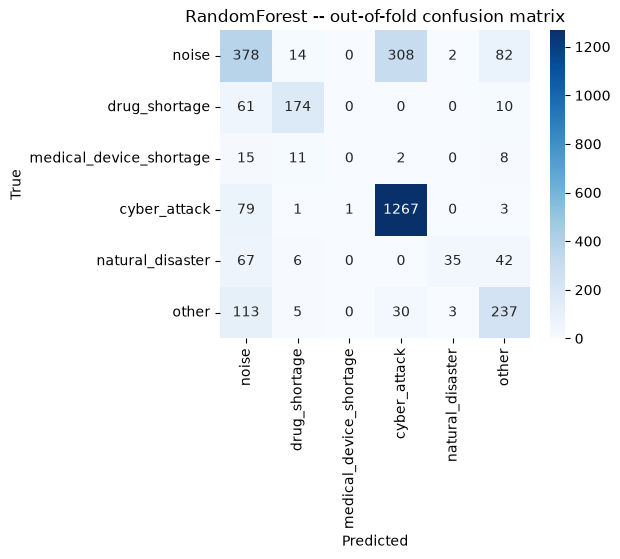

LogisticRegression
Accuracy per fold: [0.6937 0.6904 0.6954 0.6701 0.6881]
Mean accuracy: 0.6875 ± 0.0091

Classification report (out-of-fold):
                         precision    recall  f1-score   support

                  noise       0.51      0.48      0.50       784
          drug_shortage       0.80      0.81      0.81       245
medical_device_shortage       0.31      0.22      0.26        36
           cyber_attack       0.81      0.83      0.82      1351
       natural_disaster       0.63      0.60      0.61       150
                  other       0.58      0.61      0.59       388

               accuracy                           0.69      2954
              macro avg       0.61      0.59      0.60      2954
           weighted avg       0.68      0.69      0.68      2954



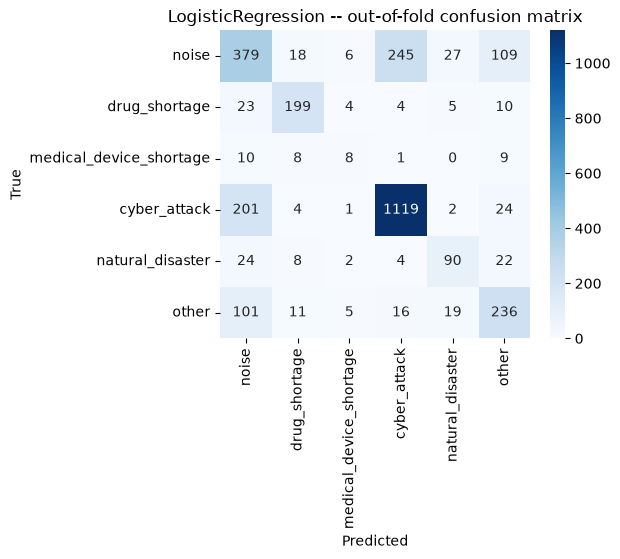

SVC
Accuracy per fold: [0.7563 0.7259 0.7614 0.7377 0.7593]
Mean accuracy: 0.7481 ± 0.0139

Classification report (out-of-fold):
                         precision    recall  f1-score   support

                  noise       0.62      0.48      0.54       784
          drug_shortage       0.79      0.86      0.82       245
medical_device_shortage       0.75      0.08      0.15        36
           cyber_attack       0.81      0.94      0.87      1351
       natural_disaster       0.70      0.61      0.65       150
                  other       0.68      0.69      0.68       388

               accuracy                           0.75      2954
              macro avg       0.72      0.61      0.62      2954
           weighted avg       0.74      0.75      0.73      2954



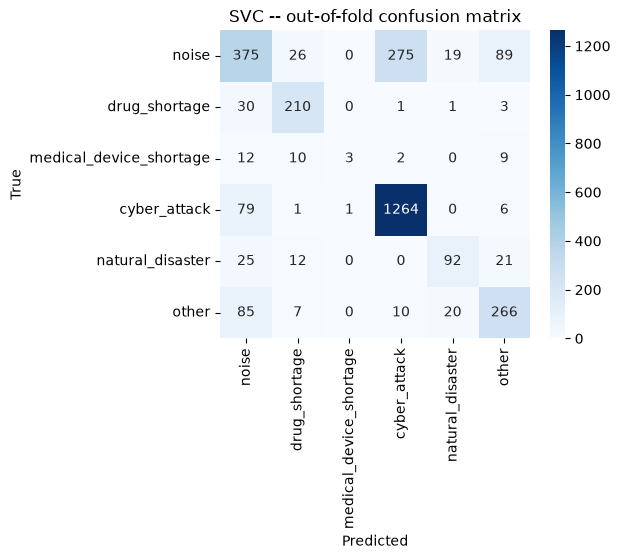

MLP
Accuracy per fold: [0.7225 0.6954 0.7157 0.6904 0.7068]
Mean accuracy: 0.7062 ± 0.0120

Classification report (out-of-fold):
                         precision    recall  f1-score   support

                  noise       0.55      0.48      0.51       784
          drug_shortage       0.78      0.80      0.79       245
medical_device_shortage       0.35      0.19      0.25        36
           cyber_attack       0.81      0.87      0.84      1351
       natural_disaster       0.61      0.64      0.62       150
                  other       0.61      0.61      0.61       388

               accuracy                           0.71      2954
              macro avg       0.62      0.60      0.60      2954
           weighted avg       0.70      0.71      0.70      2954



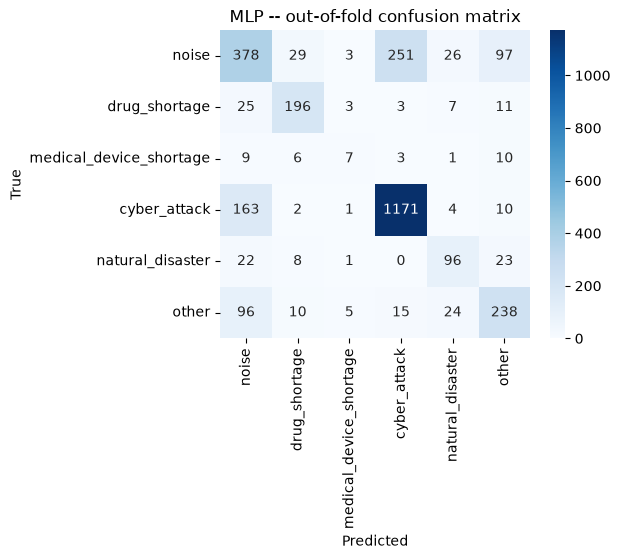

Summary -- algorithms ranked by mean 5-fold accuracy
------------------------------------------------------------
1. SVC                  0.7481 ± 0.0139
2. RandomForest         0.7079 ± 0.0194
3. MLP                  0.7062 ± 0.0120
4. LogisticRegression   0.6875 ± 0.0091


In [9]:
run_experiment(X_classic,y)

# BERT

In [10]:
#bert_path = "google-bert/bert-base-uncased"
bert_path = "microsoft/deberta-v3-base"

tokenizer = AutoTokenizer.from_pretrained(bert_path)

model = AutoModelForSequenceClassification.from_pretrained(
    bert_path,
    num_labels = 6,
    id2label = IDX_TO_LABEL,
    label2id = LABEL_MAP,
)

/Users/edgarriosnegrete/Healthcare-GPT/.venv/lib/python3.12/site-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
MAX_LEN = 256  # same window MiniLM effectively saw; bump to 512 later if curious (2x slower)

bert_texts = text.tolist()  # same input text as the classic models

train_idx, val_idx = train_test_split(
    np.arange(len(bert_texts)), test_size=0.2, stratify=y, random_state=SEED
)

class LablrDataset(Dataset):
    def __init__(self, texts, labels):
        self.enc = tokenizer(texts, truncation=True, max_length=MAX_LEN)
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item["labels"] = int(self.labels[i])
        return item

train_ds = LablrDataset([bert_texts[i] for i in train_idx], y[train_idx])
val_ds = LablrDataset([bert_texts[i] for i in val_idx],  y[val_idx])
print(len(train_ds), "train /", len(val_ds), "val")


2363 train / 591 val


In [12]:
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

class_weights = torch.tensor(
    compute_class_weight("balanced", classes=np.arange(len(CLASS_NAMES)), y=y[train_idx]),
    dtype=torch.float32,
)

def weighted_loss(outputs, labels, num_items_in_batch=None):
    return nn.functional.cross_entropy(
        outputs.logits, labels, weight=class_weights.to(outputs.logits.device)
    )

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }


In [ ]:
training_args = TrainingArguments(
    output_dir="../src/models/bert_lablr", 
    learning_rate=2e-5, 
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    logging_steps=25,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    compute_loss_func=weighted_loss,
)

trainer.train()


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.
/Users/edgarriosnegrete/Healthcare-GPT/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.427800,1.258076,0.642978,0.452620
2,0.940000,1.024019,0.729272,0.582481
3,0.907400,0.952911,0.747885,0.617024
4,0.739200,0.970427,0.742809,0.629597


/Users/edgarriosnegrete/Healthcare-GPT/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/edgarriosnegrete/Healthcare-GPT/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/edgarriosnegrete/Healthcare-GPT/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=592, training_loss=1.0840677039043323, metrics={'train_runtime': 1124.6489, 'train_samples_per_second': 8.404, 'train_steps_per_second': 0.526, 'total_flos': 1243529805901824.0, 'train_loss': 1.0840677039043323, 'epoch': 4.0})

/Users/edgarriosnegrete/Healthcare-GPT/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


BERT holdout acc: 0.7428 | macro F1: 0.6296
                         precision    recall  f1-score   support

                  noise       0.60      0.38      0.46       157
          drug_shortage       0.90      0.92      0.91        49
medical_device_shortage       0.00      0.00      0.00         7
           cyber_attack       0.79      0.89      0.84       270
       natural_disaster       0.74      0.93      0.82        30
                  other       0.67      0.85      0.75        78

               accuracy                           0.74       591
              macro avg       0.61      0.66      0.63       591
           weighted avg       0.72      0.74      0.72       591



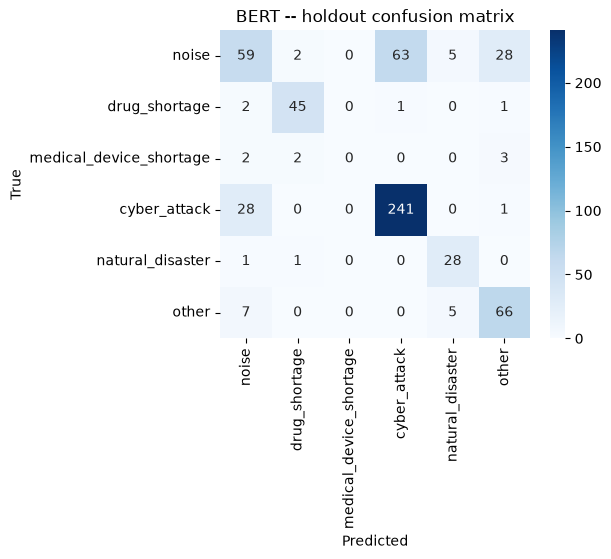

In [14]:
pred = trainer.predict(val_ds)
y_val_true = y[val_idx]
y_val_pred = pred.predictions.argmax(axis=-1)

print(f"BERT holdout acc: {accuracy_score(y_val_true, y_val_pred):.4f}"
      f" | macro F1: {f1_score(y_val_true, y_val_pred, average='macro'):.4f}")
print(classification_report(y_val_true, y_val_pred,
      labels=range(len(CLASS_NAMES)), target_names=CLASS_NAMES, zero_division=0))

cm = confusion_matrix(y_val_true, y_val_pred, labels=range(len(CLASS_NAMES)))
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("BERT -- holdout confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
